In [13]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib

# 解决中文显示问题
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

from scipy.ndimage import center_of_mass

# 读取 PSF 图像
psf = cv2.imread('1.png', cv2.IMREAD_GRAYSCALE).astype(np.float32)
psf /= 255.0  # 归一化到 0-1

# 获取图像尺寸
h, w = psf.shape
print(f"PSF 尺寸：{h} x {w}")

# 几何中心
geo_center_y, geo_center_x = h // 2, w // 2
print(f"几何中心坐标：({geo_center_x}, {geo_center_y})")

# 方法 A: 找到最亮像素的坐标
max_idx = np.unravel_index(np.argmax(psf), psf.shape)
max_y, max_x = max_idx
print(f"最亮点坐标：({max_x}, {max_y})")

# 方法 B: 计算质心（更稳健，考虑能量分布）
cy, cx = center_of_mass(psf)
print(f"质心坐标：({cx:.2f}, {cy:.2f})")

# 计算偏移量
offset_x = geo_center_x - cx
offset_y = geo_center_y - cy
print(f"需要移动的偏移量：dx={offset_x:.2f}, dy={offset_y:.2f}")

# 判断是否需要调整
threshold = 5  # 像素阈值，超过5像素建议调整
if abs(offset_x) > threshold or abs(offset_y) > threshold:
    print("⚠️  PSF 中心偏离较大，建议调整！")
else:
    print("✅ PSF 中心基本对齐，可直接使用")

PSF 尺寸：560 x 560
几何中心坐标：(280, 280)
最亮点坐标：(263, 272)
质心坐标：(269.58, 289.84)
需要移动的偏移量：dx=10.42, dy=-9.84
⚠️  PSF 中心偏离较大，建议调整！


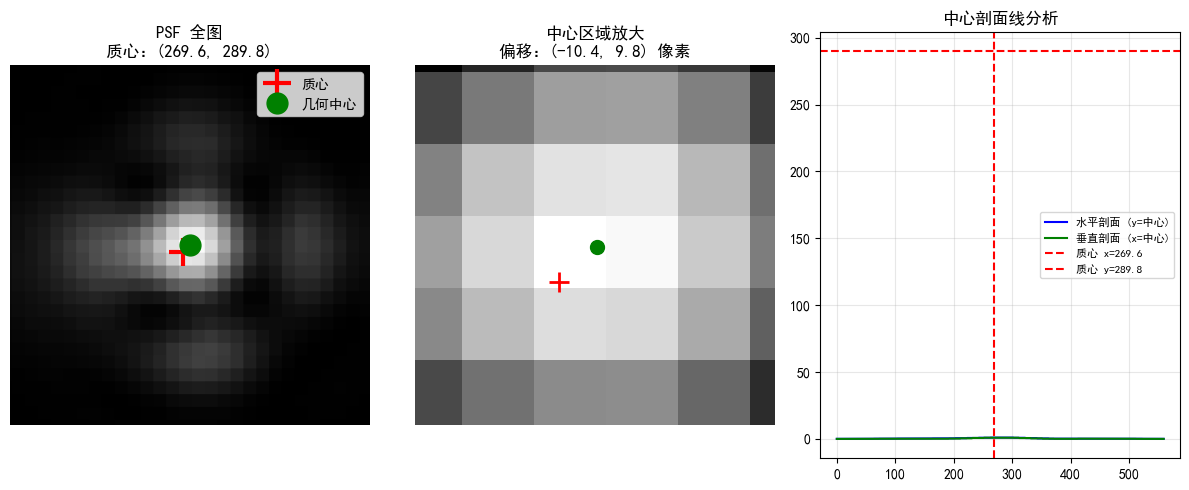

In [14]:
def visualize_psf_center(psf):
    """可视化 PSF 中心位置"""
    h, w = psf.shape
    geo_cy, geo_cx = h // 2, w // 2
    cy, cx = center_of_mass(psf)
    
    plt.figure(figsize=(12, 5))
    
    # 图 1: 完整 PSF
    plt.subplot(1, 3, 1)
    plt.imshow(psf, cmap='gray')
    plt.plot(cx, cy, 'r+', markersize=20, markeredgewidth=3, label='质心')
    plt.plot(geo_cx, geo_cy, 'go', markersize=15, label='几何中心')
    plt.title(f"PSF 全图\n质心：({cx:.1f}, {cy:.1f})")
    plt.legend()
    plt.axis('off')
    
    # 图 2: 中心区域放大 (以几何中心为中心裁剪 100x100)
    crop_size = 100
    y1, y2 = max(0, geo_cy - crop_size//2), min(h, geo_cy + crop_size//2)
    x1, x2 = max(0, geo_cx - crop_size//2), min(w, geo_cx + crop_size//2)
    psf_crop = psf[y1:y2, x1:x2]
    
    plt.subplot(1, 3, 2)
    plt.imshow(psf_crop, cmap='gray')
    # 在裁剪图中重新计算质心位置
    local_cx, local_cy = cx - x1, cy - y1
    plt.plot(local_cx, local_cy, 'r+', markersize=15, markeredgewidth=2)
    plt.plot(crop_size//2, crop_size//2, 'go', markersize=10)
    plt.title(f"中心区域放大\n偏移：({cx-geo_cx:.1f}, {cy-geo_cy:.1f}) 像素")
    plt.axis('off')
    
    # 图 3: 水平和垂直剖面线
    plt.subplot(1, 3, 3)
    plt.plot(psf[geo_cy, :], 'b-', label='水平剖面 (y=中心)')
    plt.plot(psf[:, geo_cx], 'g-', label='垂直剖面 (x=中心)')
    plt.axvline(cx, color='r', linestyle='--', label=f'质心 x={cx:.1f}')
    plt.axhline(cy, color='r', linestyle='--', label=f'质心 y={cy:.1f}')
    plt.title("中心剖面线分析")
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 运行可视化
visualize_psf_center(psf)

原始 PSF 尺寸：560 x 560
质心位置：(269.58, 289.84)
几何中心：(280, 280)
偏移量：dx=10.42, dy=-9.84
正在调整 PSF 中心...
调整后质心：(279.21, 280.10)
PSF 总和：1.000000
已保存调整后的 PSF：psf.png (按最大值线性拉伸)


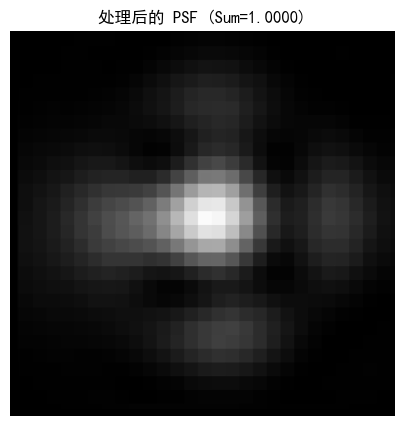

In [15]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass, shift

def preprocess_psf(psf_path, target_shape=None):
    """
    完整的 PSF 预处理流程
    """
    # 1. 读取图像
    psf = cv2.imread(psf_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
    psf /= 255.0
    
    h, w = psf.shape
    print(f"原始 PSF 尺寸：{h} x {w}")
    
    # 2. 检测中心
    geo_cy, geo_cx = h // 2, w // 2
    cy, cx = center_of_mass(psf)
    offset_x = geo_cx - cx
    offset_y = geo_cy - cy
    
    print(f"质心位置：({cx:.2f}, {cy:.2f})")
    print(f"几何中心：({geo_cx}, {geo_cy})")
    print(f"偏移量：dx={offset_x:.2f}, dy={offset_y:.2f}")
    
    # 3. 如果需要，移动 PSF 到中心
    if abs(offset_x) > 1 or abs(offset_y) > 1:
        print("正在调整 PSF 中心...")
        psf = shift(psf, shift=(offset_y, offset_x), mode='constant', cval=0.0)
        
        # 验证调整后的中心
        cy_new, cx_new = center_of_mass(psf)
        print(f"调整后质心：({cx_new:.2f}, {cy_new:.2f})")
    
    # 4. 如果需要填充到目标尺寸
    if target_shape is not None:
        h_tgt, w_tgt = target_shape
        if h != h_tgt or w != w_tgt:
            print(f"填充 PSF 到目标尺寸：{h_tgt} x {w_tgt}")
            pad_top = (h_tgt - h) // 2
            pad_bottom = h_tgt - h - pad_top
            pad_left = (w_tgt - w) // 2
            pad_right = w_tgt - w - pad_left
            psf = np.pad(psf, ((pad_top, pad_bottom), (pad_left, pad_right)), 
                        mode='constant', constant_values=0)
    
    # 5. 归一化
    psf /= np.sum(psf)
    print(f"PSF 总和：{np.sum(psf):.6f}")
    
    return psf

# 使用示例
psf_processed = preprocess_psf('1.png', target_shape=(560, 560))

# 保存为 psf.png（按最大值线性拉伸到 0-255，避免全黑）
save_path = 'psf.png'
psf_norm = psf_processed - psf_processed.min()
psf_norm = psf_norm / (psf_norm.max() + 1e-12)
psf_uint8 = (psf_norm * 255).clip(0, 255).astype(np.uint8)
cv2.imwrite(save_path, psf_uint8)
print(f"已保存调整后的 PSF：{save_path} (按最大值线性拉伸)")

# 可视化验证
plt.figure(figsize=(5, 5))
plt.imshow(psf_processed, cmap='gray')
plt.title(f"处理后的 PSF (Sum={np.sum(psf_processed):.4f})")
plt.axis('off')
plt.show()